# Neural Networks Homework

####  List of exercises
>  - **Exercise 1**: Learning Curves with FFNN using the MNIST dataset.

<br>
<div class="alert alert-info">
<b style="font-size: 25px;"> Learning Curves with FFNN on MNIST </b>
</div>

### Objectives
- Train a feedforward neural network on the MNIST dataset.
- Plot training and validation loss and accuracy over epochs.
- Learn how to interpret learning curves to detect underfitting, overfitting, and optimal training behavior.


### Instructions
1. Load and prepare (i.e. normalize pixel values to [0, 1]) the MNIST dataset
2. Scale data (for better convergence)
3. Train the MLPClassifier and Track Learning Curves
   - Use a single hidden with 8 hidden nodes
   - Use a ReLU activation function
   - Set solver to 'adam', and batch_size=128
   - Use an initial learning rate of 0.1
   - To manually simulate learning curve, set `warm_start=True`
5. Plot the Learning Curves
   - Plot Epoch vs Training Accuracy
   - Plot Epoch vs Validation Accuracy (on the same plot)
   - Annotate your plot
6. Visualization of MLP weights on MNIST (starter code provided)
   
   - Visualizing learned coefficients of a neural network can provide insight into the learning behavior. E.g.,  if weights look unstructured, maybe some were not used at all, or if very large coefficients exist, maybe regularization was too low or the learning rate too high.
    
   - You wil plot some of the first layer weights in a MLPClassifier trained on the MNIST dataset using provided code. The first layer weight matrix has the shape (784, hidden_layer_sizes[0]) and, therefore, we can visualize a single column of the weight matrix as a 28x28 pixel image. Run the code provided and describe what you observe.

7. Systematically:
    - Experiment with:
         - Number of nodes in the hidden layer
         - Different values for `learning_rate_init`
         - Different activation functions: 'logistic', 'tanh', 'relu'

8. Reflect:

    - How does changing the number of hidden units (keeping the layer size the same) affect learning behavior?
    - What do you observe does as `learning_rate_init` changes?
    - What does it mean if training accuracy keeps rising but validation accuracy stagnates or drops?
    - Effect of the choice of the activation function
    - What is your optimal combination of number of nodes in the hidden layer, initial learning rate, and activation function?

<br>
<div class="alert alert-info">
  <b style="font-size: 25px;">Your Solution Here</b>
</div>

/databricks/python/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(
/databricks/python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/spark-32982df4-5c88-4643-9362-40/.ipykernel/3119/command-7540326057283637-1706298855:38: RuntimeWarning: divide by zero encountered in log
  val_loss.append(-np.mean(np.log(val_pred[np.arange(len(y_val)), y_val])))
/databricks/python/lib/python3.11/site-packages/sklearn/neural_network/_multil

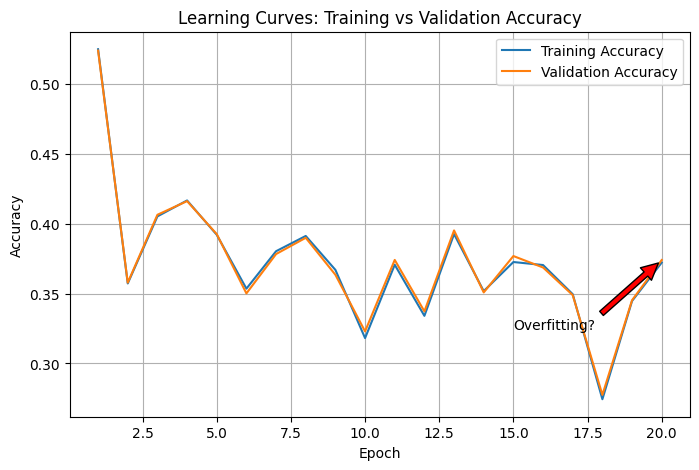

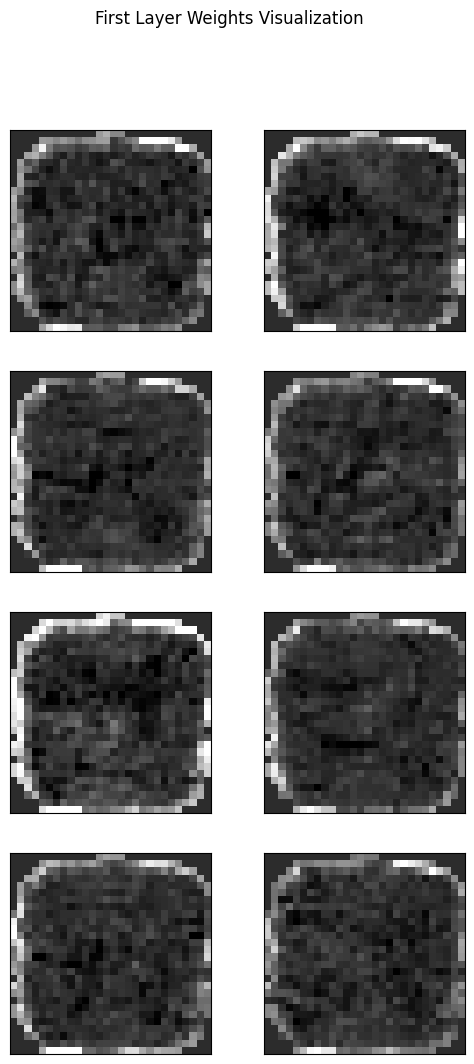

/databricks/python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/databricks/python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/databricks/python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/databricks/python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/databricks/python/lib/python3.11/site-packages/sklearn/

nodes,lr,activation,train_acc,val_acc
8,0.01,relu,0.9320535714285715,0.9152142857142858
8,0.01,tanh,0.9003035714285714,0.8809285714285714
8,0.01,logistic,0.9079821428571428,0.8891428571428571
8,0.1,relu,0.4250535714285714,0.42242857142857143
8,0.1,tanh,0.8475357142857143,0.8405714285714285
8,0.1,logistic,0.8616785714285714,0.8530714285714286
32,0.01,relu,0.968625,0.9493571428571429
32,0.01,tanh,0.9520178571428571,0.9357142857142857
32,0.01,logistic,0.9701964285714286,0.9439285714285715
32,0.1,relu,0.8935178571428571,0.8787857142857143


In [0]:
# %pip install scikit-learn matplotlib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load and normalize MNIST
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(np.int64)

# Step 2: Split and scale data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Step 3: Train MLPClassifier and track learning curves
epochs = 20
clf = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', solver='adam',
                    batch_size=128, learning_rate_init=0.1, warm_start=True, max_iter=1, random_state=42)

train_acc = []
val_acc = []
train_loss = []
val_loss = []

for epoch in range(epochs):
    clf.fit(X_train_scaled, y_train)
    train_acc.append(clf.score(X_train_scaled, y_train))
    val_acc.append(clf.score(X_val_scaled, y_val))
    train_loss.append(clf.loss_)
    # Validation loss approximation
    val_pred = clf.predict_proba(X_val_scaled)
    val_loss.append(-np.mean(np.log(val_pred[np.arange(len(y_val)), y_val])))

# Step 4: Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_acc, label='Training Accuracy')
plt.plot(range(1, epochs+1), val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curves: Training vs Validation Accuracy')
plt.legend()
plt.annotate('Overfitting?', xy=(epochs, val_acc[-1]), xytext=(epochs-5, val_acc[-1]-0.05),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.grid(True)
plt.show()

# Step 5: Visualization of MLP weights on MNIST (starter code)
fig, axes = plt.subplots(4, 2, figsize=(6, 12))
vmin, vmax = clf.coefs_[0].min(), clf.coefs_[0].max()
for coef, ax in zip(clf.coefs_[0].T, axes.ravel()):
    ax.matshow(coef.reshape(28, 28), cmap=plt.cm.gray, vmin=0.5 * vmin, vmax=0.5 * vmax)
    ax.set_xticks(())
    ax.set_yticks(())
plt.suptitle('First Layer Weights Visualization')
plt.show()

# Step 6: Systematic experiments (example grid search)
results = []
for nodes in [8, 32]:
    for lr in [0.01, 0.1]:
        for act in ['relu', 'tanh', 'logistic']:
            clf = MLPClassifier(hidden_layer_sizes=(nodes,), activation=act, solver='adam',
                                batch_size=128, learning_rate_init=lr, warm_start=True, max_iter=10, random_state=42)
            clf.fit(X_train_scaled, y_train)
            train_score = clf.score(X_train_scaled, y_train)
            val_score = clf.score(X_val_scaled, y_val)
            results.append({'nodes': nodes, 'lr': lr, 'activation': act,
                            'train_acc': train_score, 'val_acc': val_score})

import pandas as pd
display(pd.DataFrame(results))

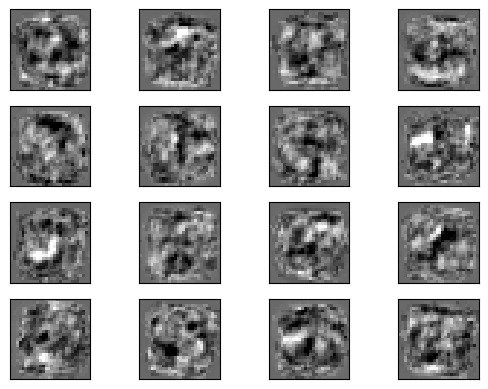

In [0]:
# Step 5: Visualization of MLP weights on MNIST
fig, axes = plt.subplots(4, 4)
# use global min / max to ensure all weights are shown on the same scale
vmin, vmax = clf.coefs_[0].min(), clf.coefs_[0].max()
for coef, ax in zip(clf.coefs_[0].T, axes.ravel()):
    ax.matshow(coef.reshape(28, 28), cmap=plt.cm.gray, vmin=0.5 * vmin, vmax=0.5 * vmax)
    ax.set_xticks(())
    ax.set_yticks(())

plt.show()


<br>
<div class="alert alert-info">
<b style="font-size: 25px;">Exercise 1: The End</b>
</div>